#### Load the Dataset

In [4]:
%store -r X_train_scaled
%store -r X_test_scaled
%store -r X_scaled
%store -r y_train
%store -r y_test
%store -r y_dataset

#### Libraries

In [5]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, KFold

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, log_loss, confusion_matrix, roc_auc_score

#### Naive Bayes Classifier

In [6]:
naive_bayes = GaussianNB()
# Fit Model
y_train_array = y_train.values.ravel()

naive_bayes.fit(X_train_scaled, y_train_array)

GaussianNB()

#### Evaluation on Training Data

In [7]:
y_train_pred = naive_bayes.predict(X_train_scaled)
y_train_pred_proba_nb = naive_bayes.predict_proba(X_train_scaled)
y_train_pred_proba_nb_normalized = y_train_pred_proba_nb / y_train_pred_proba_nb.sum(axis=1, keepdims=True)

# Precision
precision_train_nb = precision_score(y_train_array, y_train_pred, average='weighted')

# Recall
recall_train_nb = recall_score(y_train_array, y_train_pred, average='weighted')

# F1-Score
f1_train_nb = f1_score(y_train_array, y_train_pred, average='weighted')

# Accuracy
accuracy_train_nb = accuracy_score(y_train_array, y_train_pred)

# Log Loss
log_loss_value_train_nb = log_loss(y_train_array, y_train_pred_proba_nb_normalized)

# Confusion Matrix
conf_matrix_train_nb = confusion_matrix(y_train_array, y_train_pred)

# AROC Curve
roc_auc_train_nb = roc_auc_score(y_train_array, y_train_pred_proba_nb, multi_class='ovr', labels=np.unique(y_train))

# Evaluation Metrics 
print(f'Naive Bayes Training Confusion Matrix:\n{conf_matrix_train_nb}')
print()
print(f'Naive Bayes Training Area Under the ROC Curve (AROC): {roc_auc_train_nb}')
print(f'Naive Bayes Training Accuracy: {accuracy_train_nb}')
print(f'Naive Bayes Training F1-Score: {f1_train_nb}')
print(f'Naive Bayes Training Precision: {precision_train_nb}')
print(f'Naive Bayes Training Recall: {recall_train_nb}')
print(f'Naive Bayes Training Log Loss: {log_loss_value_train_nb}')

Naive Bayes Training Confusion Matrix:
[[100   0   0   0]
 [  6 112  35   0]
 [  0   0 110  39]
 [  0   0   0 198]]

Naive Bayes Training Area Under the ROC Curve (AROC): 0.9881525512248746
Naive Bayes Training Accuracy: 0.8666666666666667
Naive Bayes Training F1-Score: 0.86360092504849
Naive Bayes Training Precision: 0.8763197115318625
Naive Bayes Training Recall: 0.8666666666666667
Naive Bayes Training Log Loss: 0.5357092987493579


#### Evaluation on Test Data

In [8]:
y_test_pred = naive_bayes.predict(X_test_scaled)
y_test_pred_proba_nb = naive_bayes.predict_proba(X_test_scaled)
y_test_pred_proba_nb_normalized = y_test_pred_proba_nb / y_test_pred_proba_nb.sum(axis=1, keepdims=True)

# Precision
precision_test_nb = precision_score(y_test, y_test_pred, average='weighted')

# Recall
recall_test_nb = recall_score(y_test, y_test_pred, average='weighted')

# F1-Score
f1_test_nb = f1_score(y_test, y_test_pred, average='weighted')

# Accuracy
accuracy_test_nb = accuracy_score(y_test, y_test_pred)

# Log Loss
#log_loss_value_test_nb = log_loss(y_test, y_test_pred_proba_nb_normalized)

# Confusion Matrix
conf_matrix_test_nb = confusion_matrix(y_test, y_test_pred)

# AROC Curve
roc_auc_test_nb = roc_auc_score(y_test, y_test_pred_proba_nb, multi_class='ovr', labels=np.unique(y_train))

# Evaluation Metrics 
print(f'Naive Bayes Test Confusion Matrix:\n{conf_matrix_test_nb}')
print()
print(f'Naive Bayes Test Area Under the ROC Curve (AROC): {roc_auc_test_nb}')
print(f'Naive Bayes Test Accuracy: {accuracy_test_nb}')
print(f'Naive Bayes Test F1-Score: {f1_test_nb}')
print(f'Naive Bayes Test Precision: {precision_test_nb}')
print(f'Naive Bayes Test Recall: {recall_test_nb}')
#print(f'Naive Bayes Test Log Loss: {log_loss_value_test_nb}')

Naive Bayes Test Confusion Matrix:
[[25  0  0  0]
 [ 3 22  0  0]
 [ 0  4  9 12]
 [ 0  0  0 25]]

Naive Bayes Test Area Under the ROC Curve (AROC): 0.8891333333333333
Naive Bayes Test Accuracy: 0.81
Naive Bayes Test F1-Score: 0.7855011755158546
Naive Bayes Test Precision: 0.8536716661716661
Naive Bayes Test Recall: 0.81


### Plot Results
#### Confusion Matrix

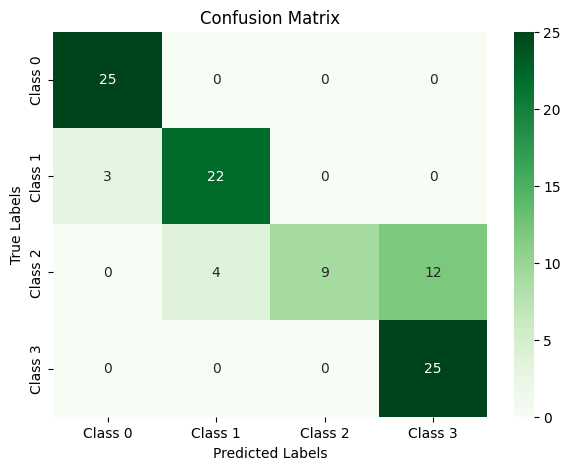

In [9]:
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix 
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Greens', xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'], yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#### Receiver Operating Characteristic (ROC) Curve

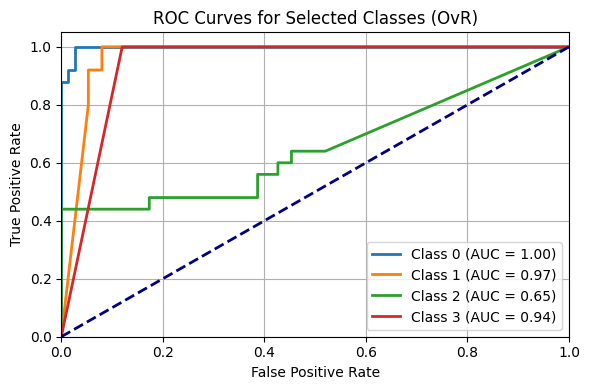

In [10]:
selected_classes = [0, 1, 2, 3]
plt.figure(figsize=(6, 4))

for class_label in selected_classes:
    y_test_binary = (y_test == class_label).astype(int)
    fpr, tpr, thresholds = roc_curve(y_test_binary, y_test_pred_proba_nb[:, class_label])
    roc_auc = auc(fpr, tpr)
    
    # Customize κάθε κλάση
    plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})', 
             color=plt.cm.get_cmap('tab10')(class_label), linestyle='-', linewidth=2)

# Plot the diagonal line 
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Selected Classes (OvR)')
plt.legend(loc='lower right')

plt.grid(True)
plt.tight_layout()
plt.show()

#### Precision, Recall, F1 Score, Accuracy

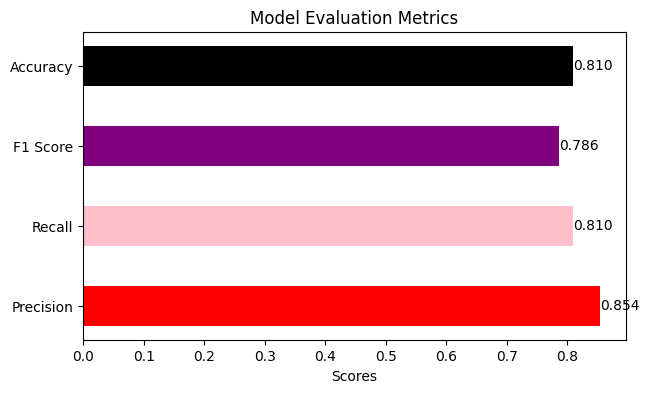

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
metrics = ['Precision', 'Recall', 'F1 Score', 'Accuracy']
scores = [precision_test_nb, recall_test_nb, f1_test_nb, accuracy_test_nb]
bar_width = 0.5

# Plot horizontal bars
bars = ax.barh(metrics, scores, height=bar_width, color=['red', 'pink', 'purple', 'black'])

# Display actual values 
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.3f}', 
             va='center', ha='left', color='black')

ax.set_xlabel('Scores')
ax.set_title('Model Evaluation Metrics')

plt.show()

#### 5fold Cross Validation

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
nb_5cross = GaussianNB()

scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'neg_log_loss', 'roc_auc_ovo_weighted']

cv_results = cross_validate(nb_5cross, X_scaled, y_dataset, cv=kf, scoring=scoring_metrics, return_train_score=False)

for fold in range(1, kf.get_n_splits() + 1):
    print(f"Fold {fold} Metrics:")
    print(f"Accuracy: {cv_results['test_accuracy'][fold-1]}")
    print(f"Precision: {cv_results['test_precision_weighted'][fold-1]}")
    print(f"Recall: {cv_results['test_recall_weighted'][fold-1]}")
    print(f"F1 Score: {cv_results['test_f1_weighted'][fold-1]}")
    print(f"Log Loss: {abs(np.mean(cv_results['test_neg_log_loss'][fold-1]))}")
    print(f"ROC AUC: {cv_results['test_roc_auc_ovo_weighted'][fold-1]}")
    print("--" * 100)

mean_metrics = {metric: np.mean(cv_results[f'test_{metric}']) for metric in scoring_metrics}

print("Mean Metrics Across Folds:")
for metric, value in mean_metrics.items():
    if metric == 'neg_log_loss':
        value = abs(value)
    print(f"{metric}: {value}")

Fold 1 Metrics:
Accuracy: 0.8357142857142857
Precision: 0.8926350642009208
Recall: 0.8357142857142857
F1 Score: 0.805005732722611
Log Loss: 2.098418979439014
ROC AUC: 0.9510309374533512
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Fold 2 Metrics:
Accuracy: 0.7785714285714286
Precision: 0.8344425349087002
Recall: 0.7785714285714286
F1 Score: 0.7626520352590135
Log Loss: 2.6627834407838664
ROC AUC: 0.9461248727963844
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Fold 3 Metrics:
Accuracy: 0.7
Precision: 0.6829670329670331
Recall: 0.7
F1 Score: 0.6522187385238939
Log Loss: 3.703615095264207
ROC AUC: 0.947070707070707
--------------------------------------------------------------------

/home/sarantis/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2981: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(
/home/sarantis/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2981: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(
/home/sarantis/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2981: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(
/home/sarantis/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2981: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(
/home/sarantis/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2981: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result 

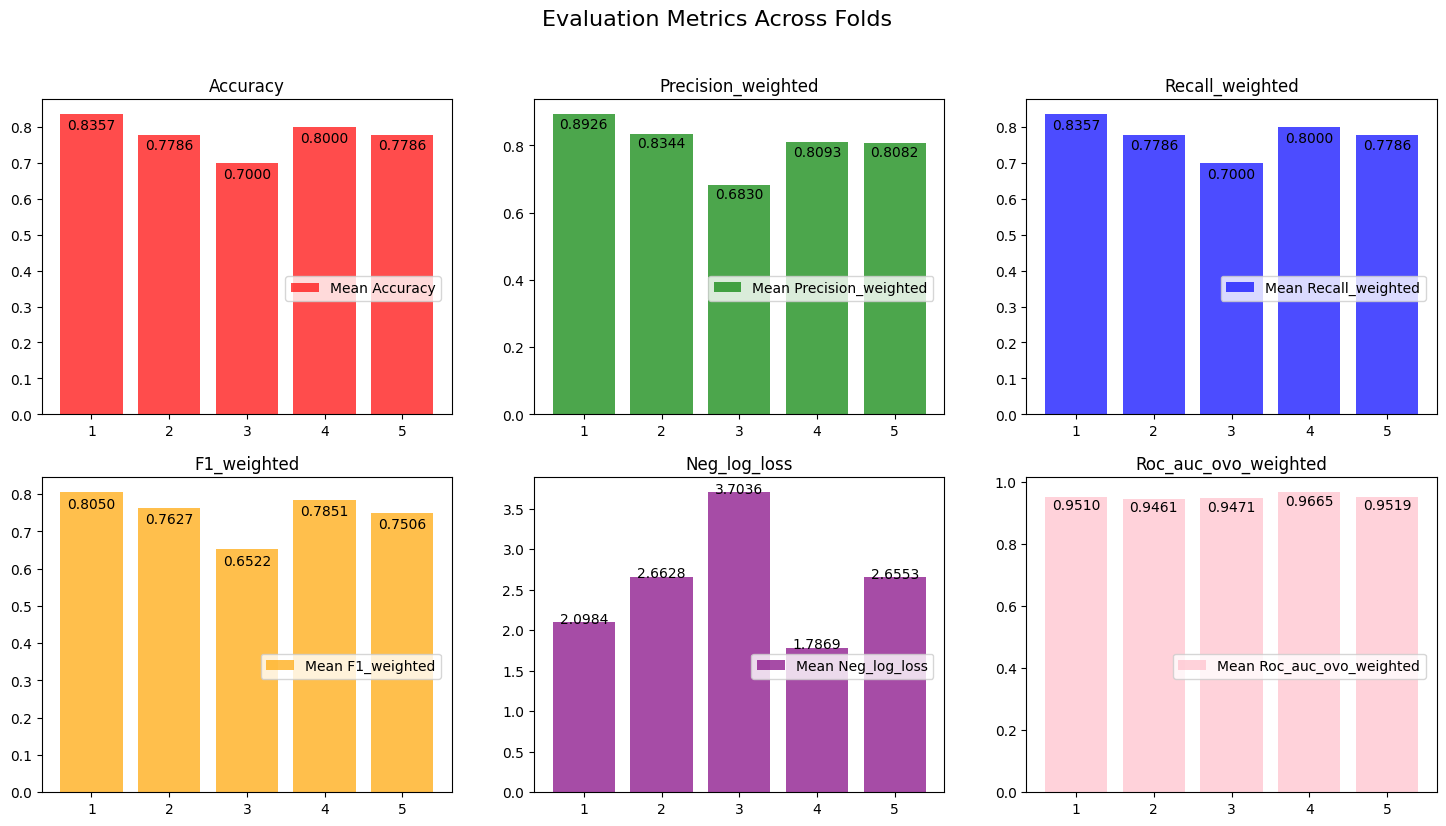

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 9))
fig.suptitle('Evaluation Metrics Across Folds', fontsize=16)

# Function for values inside the bars
def add_values(ax, values):
    for i, value in enumerate(values):
        ax.text(i + 1, value - 0.05, f'{value:.4f}', ha='center', va='bottom', color='black')

bar_height = 0.5
metrics_to_plot = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'neg_log_loss', 'roc_auc_ovo_weighted']
colors = ['red', 'green', 'blue', 'orange', 'purple', 'pink']  

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    row = idx // 3
    col = idx % 3

    if metric == 'neg_log_loss':
        metric_values = np.abs(cv_results[f'test_{metric}'])
    else:
        metric_values = cv_results[f'test_{metric}']

    bars = axes[row, col].bar(range(1, kf.get_n_splits() + 1), metric_values, color=color, alpha=0.7)
    axes[row, col].set_title(metric.capitalize())
    add_values(axes[row, col], metric_values)

    axes[row, col].legend([f'Mean {metric.capitalize()}'], loc='center right', bbox_to_anchor=(0.99, 0.4))

if len(metrics_to_plot) < 6:
    fig.delaxes(axes[-1, -1])

plt.subplots_adjust(hspace=0.2)
plt.show()
